# Can you trade the drought? 🏜️🌽
### The US Drought Monitor prints every Thursday — and the ag complex shrugs

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Drought_moves_ag%3F: Busted](https://img.shields.io/badge/Drought_moves_ag%3F-Busted-8b949e?style=flat-square)

Every Thursday morning since 2000, the **US Drought Monitor** publishes a map of how much of the country is baking in severe drought. The trade writes itself: drought means a smaller harvest, means pricier grain, means good times for the people who sell into the shortage — Deere (tractors), Mosaic (fertilizer), ADM (grain trading), and the ag/grain ETFs. So when the Monitor prints a worse number, *buy the drought.*

We tested it properly — the 21 biggest US drought escalations since 2000, against a basket of the exact names the story names.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the regime split? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 21 drought escalations hardcoded to their Thursday Monitor release; each mapped to an ag-equity basket (DE/MOS/ADM/MOO) and a grain basket (DBA/CORN/WEAT), measured *against SPY*. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from drought_monitor import data, strategy as st

PRE, POST = 1, 5
EVENTS = data.drought_events()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY, NAMES = data.load_real()
    SPY_RET = st.daily_returns(SPY)
    EQ_RET, EQ_COV = st.basket_returns(NAMES, data.AG_EQUITY_TICKERS)
    GR_RET, GR_COV = st.basket_returns(NAMES, data.GRAIN_TICKERS)
    AR_EQ = st.abnormal_vs_bench(EQ_RET, SPY_RET)
    AR_GR = st.abnormal_vs_bench(GR_RET, SPY_RET)
else:
    SPY = NAMES = SPY_RET = EQ_RET = GR_RET = AR_EQ = AR_GR = None
print("real cache present:", HAVE_REAL, "| drought escalations:", len(EVENTS))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_events': 21, 'n_grain': 16, 'cal_lo': '2000-08-03', 'cal_hi': '2025-05-15', 'fp': '9261c00637a8', 'eq_day0_bps': -24.28, 'eq_day0_t': -0.84, 'eq_up': 9, 'eq_n': 21, 'eq_wilson': (24.5, 63.5), 'gr_day0_bps': -71.01, 'gr_day0_t': -1.3, 'gr_up': 8, 'gr_n': 16, 'gr_wilson': (28.0, 72.0), 'eq_pl_mean_bps': 2.1, 'eq_pl_sd_bps': 27.63, 'eq_pl_p': 0.837, 'gr_pl_mean_bps': -4.69, 'gr_pl_sd_bps': 39.24, 'gr_pl_p': 0.958, 'pl_draws': 20000, 'event': {-1: (-32.54, 0.0, -1.37), 0: (-24.28, -24.28, -0.84), 1: (-2.66, -26.94, -0.16), 2: (27.66, 0.72, 0.91), 3: (29.84, 30.56, 1.46), 4: (-18.37, 12.18, -0.74), 5: (40.8, 52.99, 2.17)}, 'drift_bps': 77.27, 'drift_t': 1.56, 'drift_pl_p': 0.137, 'drift_ci': (-9.2, 177.8), 'grain_mean_bps': -71.01, 'equity_mean_bps': -33.64, 'diff_bps': -37.36, 'diff_t': -0.83, 'diff_n': 16, 'timer': {1: (-2.66, -12.66, -0.74, 48, 2.05), 5: (77.27, 67.27, 1.36, 67, 10.06), 10: (84.29, 74.29, 1.14, 62, 19.77), 21: (73.8, 63.8, 0.49, 62, 41.39)}, 'timer_net10_5d': 57.27, 'timer_net10_5d_t': 1.15, 'reg_n': 305, 'reg_thr': 20, 'reg_hi_n': 115, 'reg_lo_n': 190, 'reg_hi_bps': 42.85, 'reg_lo_bps': 50.46, 'reg_welch_t': -0.11, 'reg_hi_t': 0.82, 'reg_timer_net_bps': 32.85, 'syn_null_mean': 0.02, 'syn_null_sd': 1.07, 'syn_null_fire': 0, 'syn_null_seeds': 20, 'syn_planted1_t': 2.93, 'syn_planted2_t': 7.59, 'syn_planted2_bps': 160.9}


real cache present: True | drought escalations: 21


## The answer first

| Question | Answer |
|---|---|
| Does the ag complex pop on the drought print? | **No.** It drifts *down* **-24 bps** vs the market — the wrong sign, and statistically nothing (*t* = −0.84). |
| Does grain at least react? | **No — and if anything, worse** (**-71 bps**, *t* = −1.30). Grain markets priced the weather forecast weeks before the Monitor confirmed it. |
| Could you "buy the drought"? | **Not reliably.** The best horizon (5 days) nets **+67 bps** — but at *t* = +1.36, short of the bar, and it fades away by 21 days. |
| Do high-drought *months* favour ag? | **No.** Ag is a hair *behind* the market in the driest third of months (Welch *t* = -0.11). |

> The story is intuitive and completely undetectable. The weekly Monitor is old news to a market that prices the forecast in real time.

## 1 · The claim

> *"When the US Drought Monitor shows severe drought spreading across the crop belt, the harvest outlook worsens, grain gets scarcer and pricier, and the ag names — farm equipment, fertilizer, grain traders, the ag ETFs — get a tailwind. Read the Thursday print and buy the drought."*

It rides on something real: weather genuinely moves agricultural commodity *prices* (the 2012 Corn Belt drought sent corn futures to record highs). The open question is narrower — is the **public, weekly, pre-scheduled Monitor print itself** a tradable event for US-listed ag stocks and ETFs? Or is the drought already fully in prices by the time the Monitor confirms it?

## 2 · So what?

If real, this would be a clean, mechanical, weather-driven edge: a free government data release every Thursday, a basket of liquid names to express it, a supply-shock story any commodity desk would nod along to. Weather trades are a whole cottage industry. We wanted to know: does *this* one — the most-watched public drought index in the world — actually pay?

## 3 · How we'd know

- **The calendar.** **21** major US drought escalations 2000→2025, each dated to a representative **Thursday** Drought Monitor release during the rapid-worsening phase (2011 Texas, 2012 Corn Belt, 2012–15 California, 2021–22 Western megadrought, 2023 Midwest…).
- **The names.** An ag-equity basket (Deere `DE`, Mosaic `MOS`, ADM, agribusiness ETF `MOO`) and a grain basket (broad-ag `DBA`, corn `CORN`, wheat `WEAT`), each measured **against SPY** — so a result means "ag beat the market", not "stocks went up".
- **The lag.** The Monitor is public Thursday ~8:30am, before the close, so we enter at that **Thursday's close** — zero look-ahead.
- **The honesty check.** A random-calendar placebo (does a random Thursday produce the same move just as often?), a grain-vs-equity test, a costed "buy the drought" timer, and a drought-*regime* split on a labelled monthly severity proxy.

## 4 · The teardown — let's actually look

**First, the headline: what does the ag complex do on the print day?**

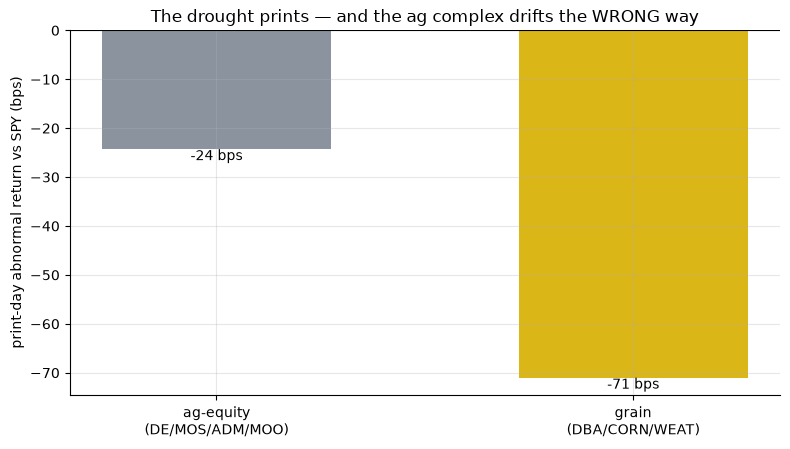

ag-equity -24.28 bps   grain -71.01 bps


In [2]:
if HAVE_REAL:
    d0e = st.day0_stats(AR_EQ, EVENTS['date'], PRE, POST)
    d0g = st.day0_stats(AR_GR, EVENTS['date'], PRE, POST)
    eq, gr = d0e['mean']*1e4, d0g['mean']*1e4
else:
    eq, gr = R['eq_day0_bps'], R['gr_day0_bps']
fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.bar(['ag-equity\n(DE/MOS/ADM/MOO)', 'grain\n(DBA/CORN/WEAT)'], [eq, gr],
       color=[GREY, AMBER], width=.55)
for i, v in enumerate([eq, gr]): ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('print-day abnormal return vs SPY (bps)')
ax.set_title('The drought prints — and the ag complex drifts the WRONG way')
plt.tight_layout(); plt.show()
print(f'ag-equity {eq:+.2f} bps   grain {gr:+.2f} bps')

On the day the bad news is confirmed, the ag-equity basket is **-24 bps** vs the market and grain is **-71 bps** — both *negative*, the opposite of the claim, and both statistically indistinguishable from zero (*t* = -0.84 / -1.30). The up-rate is 9/21 = 42.9% for the equities — a coin flip.

**Is that just a small, noisy sample? Compare it to random Thursdays.**

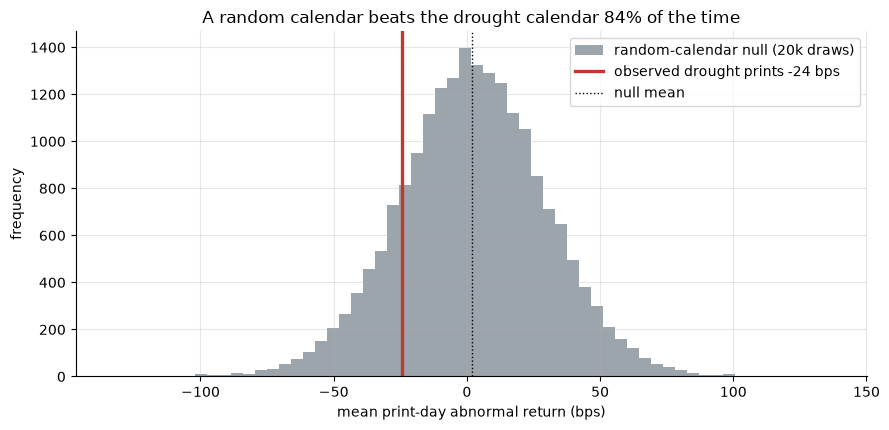

observed -24.28 bps, placebo p = 0.837


In [3]:
if HAVE_REAL:
    d0e = st.day0_stats(AR_EQ, EVENTS['date'], PRE, POST)
    draws = np.concatenate([st.placebo_distribution(AR_EQ, d0e['n'], PRE, POST,
                            n_draws=1000, seed=740+s, stat='day0') for s in range(20)])*1e4
    obs = d0e['mean']*1e4
else:
    rng = np.random.default_rng(740)
    draws = rng.normal(R['eq_pl_mean_bps'], R['eq_pl_sd_bps'], R['pl_draws'])
    obs = R['eq_day0_bps']
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.hist(draws, bins=60, color=GREY, alpha=.85, label='random-calendar null (20k draws)')
ax.axvline(obs, c=RED, lw=2.4, label=f'observed drought prints {obs:+.0f} bps')
ax.axvline(float(np.mean(draws)), c='k', lw=1, ls=':', label='null mean')
ax.set_xlabel('mean print-day abnormal return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'A random calendar beats the drought calendar {R["eq_pl_p"]*100:.0f}% of the time')
ax.legend(); plt.tight_layout(); plt.show()
print(f"observed {R['eq_day0_bps']:+.2f} bps, placebo p = {R['eq_pl_p']:.3f}")

The observed drought-print move sits **inside the bulk** of the random-calendar cloud — right-tail *p* = **0.837** for the equities, **0.958** for grain. Picking 21 random Thursdays does at least as well as picking the 21 worst drought weeks. There is no print-day reaction to find.

**Does the reaction just show up a bit later? Here's the whole week.**

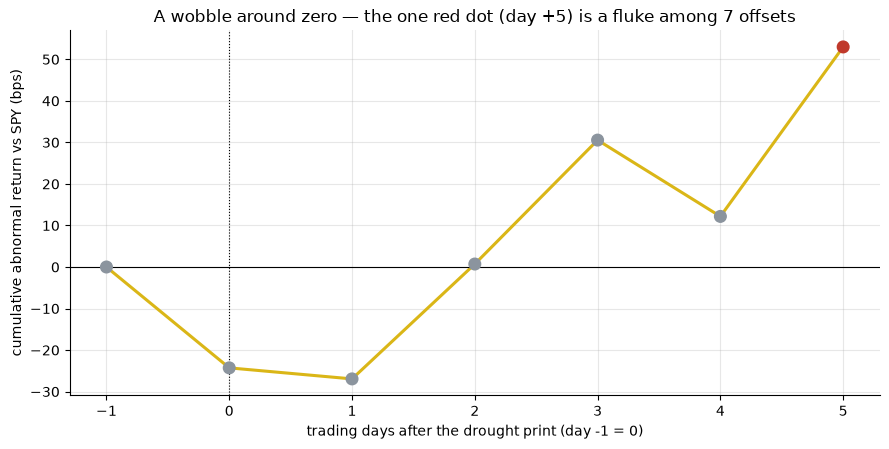

CAR by day (bps): [0.0, -24.3, -26.9, 0.7, 30.6, 12.2, 53.0]


In [4]:
if HAVE_REAL:
    cp = st.car_path_stats(AR_EQ, EVENTS['date'], PRE, POST)
    days = list(cp.index); car = list(cp['car']*1e4); ts = list(cp['t'])
else:
    days = sorted(R['event']); car = [R['event'][k][1] for k in days]
    ts = [R['event'][k][2] for k in days]
fig, ax = plt.subplots(figsize=(9.0, 4.6))
cols = [RED if abs(t) >= 2 else GREY for t in ts]
ax.plot(days, car, color=AMBER, lw=2.2, marker='o')
ax.scatter(days, car, c=cols, s=70, zorder=5)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, ls=':', c='k', lw=.8)
ax.set_xlabel('trading days after the drought print (day -1 = 0)')
ax.set_ylabel('cumulative abnormal return vs SPY (bps)')
ax.set_title('A wobble around zero — the one red dot (day +5) is a fluke among 7 offsets')
plt.tight_layout(); plt.show()
print('CAR by day (bps):', [round(c,1) for c in car])

The cumulative path just **wanders around zero**. Exactly one bar (day +5) crosses the significance line — but with 7 offsets tested, roughly one crossing by pure luck is *expected*, and there's no story for why the ag complex would wake up precisely five sessions after a print and not before. That's a look-elsewhere fluke, not a delayed reaction.

**Finally — could you have banked it? "Buy the drought" and hold.**

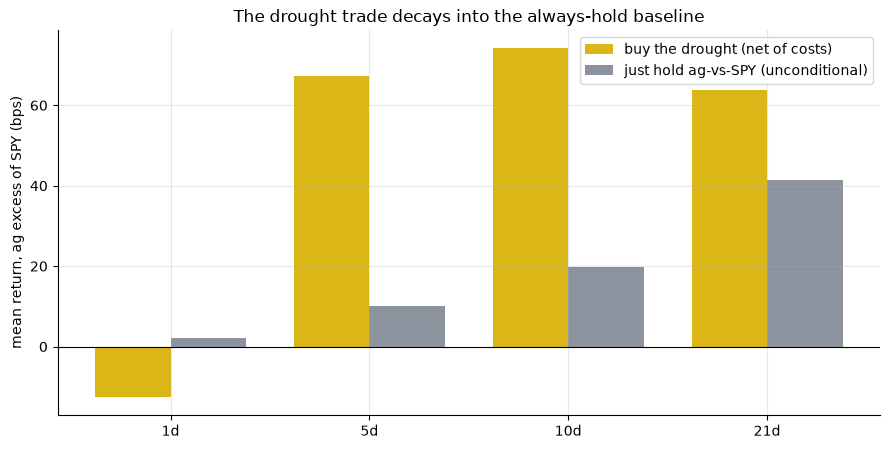

net (bps): [-12.7, 67.3, 74.3, 63.8]


In [5]:
holds = [1, 5, 10, 21]
if HAVE_REAL:
    net, base = [], []
    for h in holds:
        ln = st.trade_it(EQ_RET, SPY_RET, EVENTS['date'], hold=h, cost_bps=5.0)
        net.append(st.summarize_trade(ln, 'ret_net')['mean_bps'])
        fwd = st.abnormal_vs_bench(EQ_RET, SPY_RET).rolling(h).sum().shift(-h)
        base.append(float(fwd.mean()*1e4))
else:
    net = [R['timer'][h][1] for h in holds]; base = [R['timer'][h][4] for h in holds]
x = np.arange(len(holds)); w = 0.38
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.bar(x - w/2, net, w, color=AMBER, label='buy the drought (net of costs)')
ax.bar(x + w/2, base, w, color=GREY, label='just hold ag-vs-SPY (unconditional)')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in holds])
ax.set_ylabel('mean return, ag excess of SPY (bps)')
ax.set_title('The drought trade decays into the always-hold baseline')
ax.legend(); plt.tight_layout(); plt.show()
print('net (bps):', [round(n,1) for n in net])

The best case is a 5-day hold: **+67 bps** net, above the **+10 bps** you'd earn just holding ag-vs-SPY unconditionally. But it's only *t* = +1.36 — nowhere near the desk's bar — and by 21 days the "drought" trade (**+64 bps**) has decayed almost into the **+41 bps** unconditional drift. You're not being paid for the drought; you're being paid for owning ag stocks, drought or no drought.

## 5 · The verdict

- **Signal — None.** The print-day move is the wrong sign and insignificant for both baskets; a random calendar does as well (*p* = 0.84 / 0.96); and high-drought months carry no forward ag edge (Welch *t* = -0.11).
- **Tradability — Mirage.** No horizon of "buy the drought" clears the bar net of costs; the best (5-day) is *t* = 1.36 and decays toward the always-hold baseline.
- **"Does a drought print move the ag complex?" — Busted.** The weekly Monitor is old news to a market that prices the weather forecast weeks earlier.

## 6 · Going further 🚪

- **This is what an *efficient* public signal looks like.** The Drought Monitor is famous, free, and slow-moving — exactly the kind of information the market has already digested from weather models long before Thursday. A real weather edge, if one exists, lives in the *forecast surprise*, not the *confirmation*.
- **The natural sequel** would test grain *futures* (not equity-diluted ETFs) around USDA WASDE crop-report *surprises* — a genuine scheduled information shock — rather than the already-anticipated Monitor. That's where a supply-shock reaction, if it survives anywhere, should show up.
- **Sibling studies:** the [plane-crash effect](../../707-plane-crash-effect/) (a news-shock event study on the broad market), the [geopolitical-shock study](../../313-geopolitical-shock/), and the [FOMC vol-crush](../../637-fomc-vol-crush/) (a *scheduled public release* event study) — same machinery, different triggers.

*Think the Drought Monitor really is tradable? Bring grain futures, a forecast-surprise measure, or an intraday window around the 8:30 release, and show a net, placebo-surviving edge. We'll publish the teardown.*